**What are we doing?**  
We have demographic data for ~900,000 German citizens AND data for existing customers of a mail-order company.  
Our goal is to find `which types of people` are most likely to become customers, so the company can send marketing only to them => saving money.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

## Load Data

In [ ]:
azdias = pd.read_csv("Data/Udacity_AZDIAS_Subset.csv",sep=';')
customers = pd.read_csv("Data/Udacity_CUSTOMERS_Subset.csv",sep=';')
features_info = pd.read_csv('Data/AZDIAS_Feature_Summary.csv', sep=';')

In [3]:
azdias.shape

(891221, 85)

In [4]:
customers.shape

(191652, 85)

In [5]:
azdias.head()

,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,...,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
0,-1,2,1,2.0,3,4,3,5,5,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-1,1,2,5.0,1,5,2,5,4,5,...,2.0,3.0,2.0,1.0,1.0,5.0,4.0,3.0,5.0,4.0
2,-1,3,2,3.0,1,4,1,2,3,5,...,3.0,3.0,1.0,0.0,1.0,4.0,4.0,3.0,5.0,2.0
3,2,4,2,2.0,4,2,5,2,1,2,...,2.0,2.0,2.0,0.0,1.0,3.0,4.0,2.0,3.0,3.0
4,-1,3,1,5.0,4,3,4,1,3,2,...,2.0,4.0,2.0,1.0,2.0,3.0,3.0,4.0,6.0,5.0


In [6]:
print(azdias.dtypes.value_counts())

float64    49
int64      32
object      4
Name: count, dtype: int64


In [7]:
print('Null Count :',azdias.isnull().sum().sum())

Null Count : 4896838


## Exploring Data

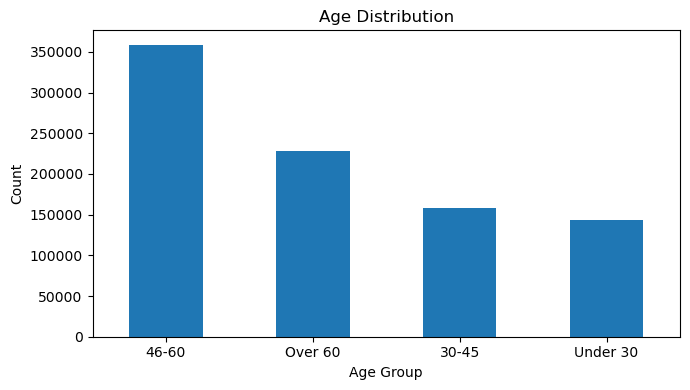

In [8]:
age_labels = {1: 'Under 30', 2: '30-45', 3: '46-60', 4: 'Over 60'}

age_counts = azdias['ALTERSKATEGORIE_GROB'].replace(-1, np.nan).dropna()
age_counts = age_counts.map(age_labels).value_counts()

plt.figure(figsize=(7, 4))
age_counts.plot(kind='bar')
plt.title('Age Distribution')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

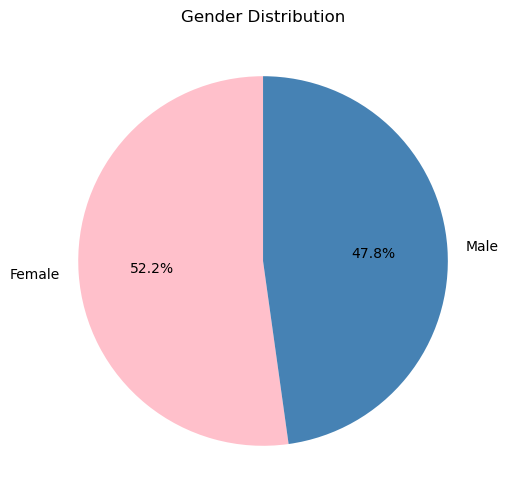

In [9]:
gender_labels = {1: 'Male', 2: 'Female'}

gender_counts = azdias['ANREDE_KZ'].replace([-1,0], np.nan).dropna()
gender_counts = gender_counts.map(gender_labels).value_counts()

plt.figure(figsize=(6, 6))
plt.pie(gender_counts,labels=gender_counts.index,autopct='%1.1f%%',startangle=90,colors=['pink','steelblue'])
plt.title('Gender Distribution')
plt.show()

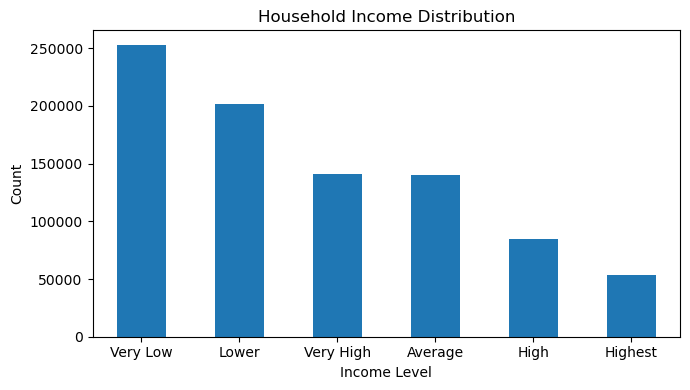

In [10]:
income_labels = {1:'Highest', 2:'Very High', 3:'High', 4:'Average', 5:'Lower', 6:'Very Low'}

income_counts = azdias['HH_EINKOMMEN_SCORE'].replace([-1,0], np.nan).dropna()
income_counts = income_counts.map(income_labels).value_counts()

plt.figure(figsize=(7, 4))
income_counts.plot(kind='bar')
plt.title('Household Income Distribution')
plt.xlabel('Income Level')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Data Cleaning

- we can find that the data has `unknown` data as **-1 , 0 , 9** not as **NaN**.
  So we need to replace it with `NaN`
- Drop columns which have >30% missing (`mostly missing`)
- Drop rows which have too missing values
- Fill remaining with **median**



In [11]:
UNKNOWN_CODES = {}

for col, val in zip(features_info['attribute'], features_info['missing_or_unknown']):
    
    val = val.strip('[]')
    
    if val: 
        codes = [int(x) if x.lstrip('-').isdigit() else x for x in val.split(',')]
        UNKNOWN_CODES[col] = codes

print(f'{len(UNKNOWN_CODES)} columns')

75 columns


In [12]:
def clean_data(df, unkown_codes, drop_cols=None, row_thresh=None):
    # df = df.copy() 

    # Replace "unkown" with NaN
    for col, vals in unkown_codes.items():
        if col in df.columns:
            ### replace instead of mask 
            df[col] = df[col].replace(vals, np.nan)

    # Drop Cols with >30% missing
    if drop_cols is None:
        missing_stats = df.isnull().mean()
        drop_cols = missing_stats[missing_stats > 0.30].index.tolist()
        drop_cols += ['CAMEO_DEU_2015']  # string column ==> not needed
    
    df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

    # Encoding
    if 'OST_WEST_KZ' in df.columns:
        df['OST_WEST_KZ'] = df['OST_WEST_KZ'].map({'O': 0, 'W': 1})

    if 'CAMEO_INTL_2015' in df.columns:
        ### 32 bits is enough for float instead of 64 bits
        df['WEALTH'] = df['CAMEO_INTL_2015'].str[0].astype(np.float32)
        df['LIFE_STAGE'] = df['CAMEO_INTL_2015'].str[1].astype(np.float32)
        df.drop('CAMEO_INTL_2015', axis=1, inplace=True)

    cat_cols = [
        'CJT_GESAMTTYP', 'FINANZTYP', 'GFK_URLAUBERTYP', 'LP_FAMILIE_FEIN', 
        'LP_FAMILIE_GROB', 'LP_STATUS_FEIN', 'LP_STATUS_GROB', 'NATIONALITAET_KZ', 
        'SHOPPER_TYP', 'ZABEOTYP', 'GEBAEUDETYP', 'CAMEO_DEUG_2015'
    ]
    cols_enc = [c for c in cat_cols if c in df.columns]
    ### 8 bits is enough as it's only zeros and ones 
    df = pd.get_dummies(df, columns=cols_enc, dtype=np.int8)
    
    # Drop Rows 
    if row_thresh is None:
        row_thresh = df.isnull().sum(axis=1).quantile(0.95)
    
    
    df = df[df.isnull().sum(axis=1) <= row_thresh].copy()

    # Fill NaN with median
    ### try converting data to 32 bit before imputing
    for col in df.columns:
        if df[col].dtype == 'float64' or df[col].dtype == 'object':
            try:
                df[col] = df[col].astype(np.float32)
            except:
                pass 
            
    imp = SimpleImputer(strategy='median')
    df_values = imp.fit_transform(df)
    df = pd.DataFrame(df_values, columns=df.columns, index=df.index)

    return df , drop_cols ,row_thresh

In [13]:
print('Before cleaning:')
print(f'General population : {azdias.shape}')
print(f'Customers          : {customers.shape}')

Before cleaning:
General population : (891221, 85)
Customers          : (191652, 85)


In [14]:
# Clean population first ==> set our thresholds
azdias_clean, dropped_cols, row_thresh = clean_data(azdias, UNKNOWN_CODES)

# Clean customers using the same thresholds
customers_clean, _, _ = clean_data(
    customers,
    UNKNOWN_CODES,
    drop_cols=dropped_cols,
    row_thresh=row_thresh
)

customers_clean = customers_clean.reindex(columns=azdias_clean.columns, fill_value=0)
print('After cleaning:')
print(f'General population : {azdias_clean.shape}')
print(f'Customers          : {customers_clean.shape}')
print(f'Columns dropped    : {len(dropped_cols)}')

After cleaning:
General population : (891221, 151)
Customers          : (191652, 151)
Columns dropped    : 7


## Feature Scalling


In [15]:
scaler = StandardScaler()
azdias_scaled = scaler.fit_transform(azdias_clean)
customers_scaled = scaler.transform(customers_clean) # only transform ==> because we only fit on population
print('Done Scalling')

Done Scalling


## Appling PCA   
* Dimentionality Reduction => `Extracting important features`

In [16]:
from sklearn.decomposition import PCA
pca = PCA()
azdias_pca = pca.fit_transform(azdias_scaled)

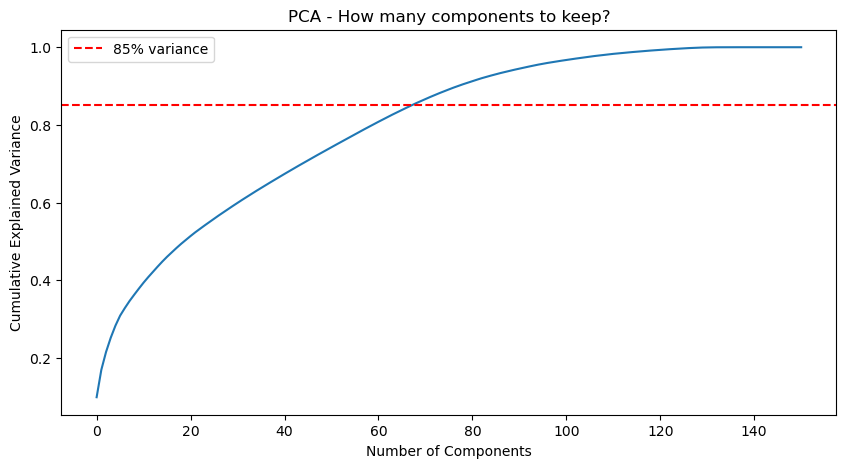

In [17]:
# Explained Variance Plot (Scree Plot)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(cumulative_variance)
plt.axhline(y=0.85, color='r', linestyle='--', label='85% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - How many components to keep?')
plt.legend()
plt.show()


In [18]:
# Number of components that explains 85% of variance
n_components = np.argmax(cumulative_variance >= 0.85) + 1
print(f'Components needed: {n_components}')

Components needed: 68


In [19]:
# Fitting the PCA with the best number of components
pca = PCA(n_components=n_components)
azdias_pca = pca.fit_transform(azdias_scaled)
customers_pca = pca.transform(customers_scaled)

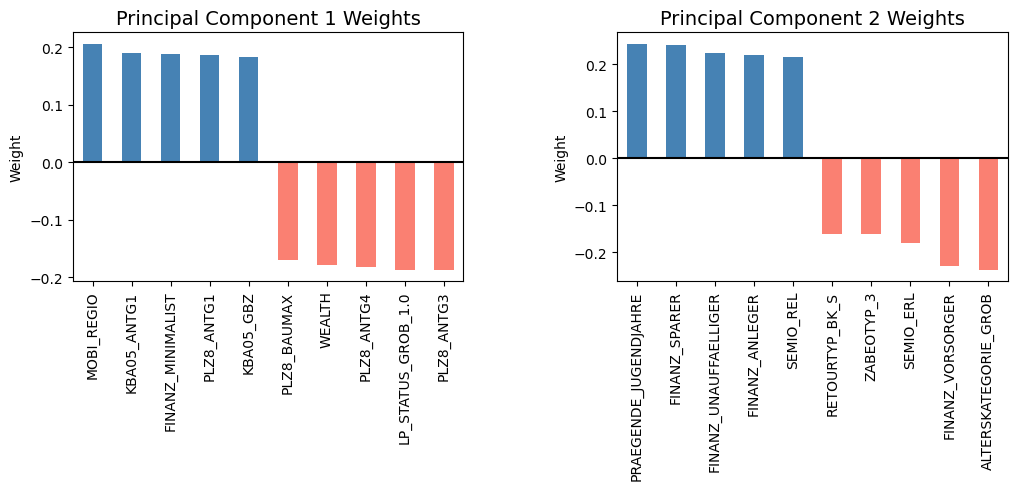

In [20]:
import math

def plot_pca_weights_grid(df, pca, n_components=4):
    # 2 plots in each row
    n_cols = 2
    n_rows = math.ceil(n_components / n_cols)
    
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
    fig.tight_layout(pad=8.0)
    
    if n_components > 1:
        axs_flat = axs.flatten()
    else:
        axs_flat = [axs]

    for i in range(n_components):
        # weights for each component
        weights = pd.DataFrame(pca.components_, columns=list(df.columns)).iloc[i]
        weights = weights.sort_values(ascending=False)
        
        # top 5 +ve and -ve features
        top_weights = pd.concat([weights.head(5), weights.tail(5)])
        
        # colour mapping blue for +ve and red for -ve 
        colors = ['steelblue' if x > 0 else 'salmon' for x in top_weights]
        
        # plotting
        top_weights.plot(kind='bar', ax=axs_flat[i], color=colors)
        
        axs_flat[i].set_title(f'Principal Component {i+1} Weights', fontsize=14)
        axs_flat[i].set_ylabel('Weight')
        axs_flat[i].axhline(0, color='black')
        axs_flat[i].tick_params(axis='x', rotation=90)


    plt.show()

# plot weights for the first 2 components
plot_pca_weights_grid(azdias_clean, pca, n_components=2)

## K_means Clustring   
 * Dividing Azdias to clusters 

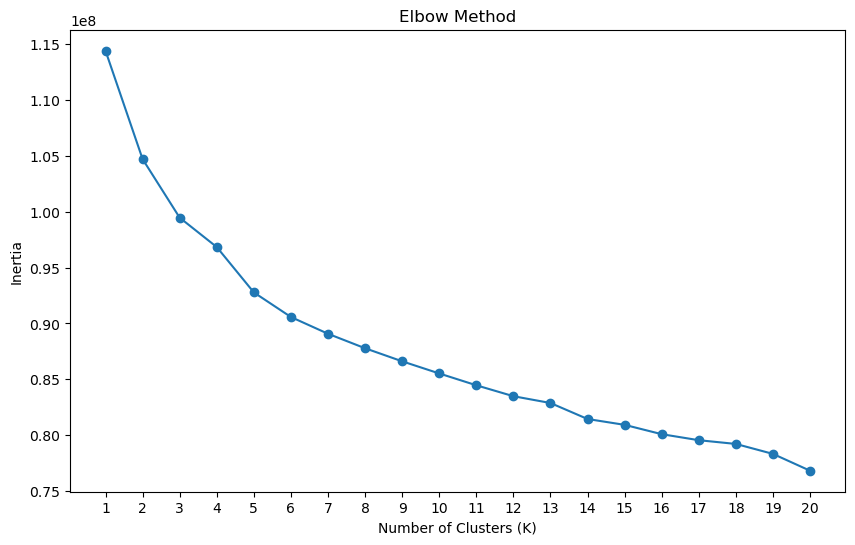

In [21]:
scores = []
k_range = range(1,21) 

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(azdias_pca)
    scores.append(abs(kmeans.score(azdias_pca)))
    
plt.figure(figsize=(10, 6))
plt.xticks(k_range)
plt.plot(k_range, scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [22]:
# Chosing the best k value
optimal_k = 10   # chosen based on elbow curve observation
 
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans.fit(azdias_pca)

azdias_clusters = kmeans.labels_
customers_clusters = kmeans.predict(customers_pca)

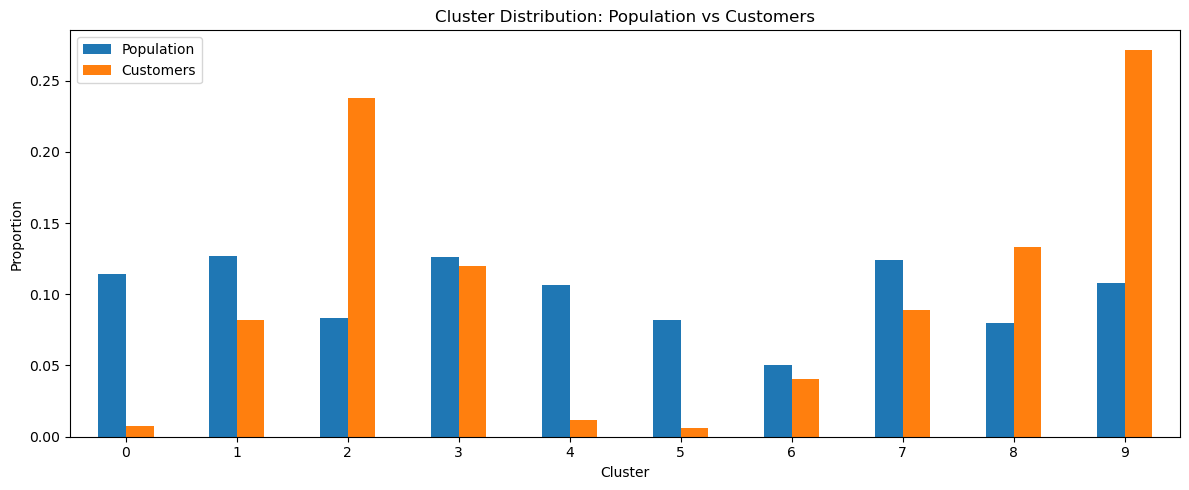

In [ ]:
pop_counts  =  pd.Series(azdias_clusters).value_counts(normalize=True).sort_index()
cust_counts =  pd.Series(customers_clusters).value_counts(normalize=True).sort_index()

comparison = pd.DataFrame({
    'Population': pop_counts,
    'Customers': cust_counts
}).fillna(0)

comparison.plot(kind='bar', figsize=(12, 5))
plt.title('Cluster Distribution: Population vs Customers')
plt.xlabel('Cluster')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
comparison['ratio'] = comparison['Customers'] / comparison['Population']

# remove tiny clusters to avoid misleading ratios
comparison = comparison[comparison['Population'] > 0.01]
comparison_sorted = comparison.sort_values('ratio', ascending=False)

print("OVER-represented clusters (TARGET customers):")
print(comparison_sorted.head(3))

print("\nUNDER-represented clusters (avoid):")
print(comparison_sorted.tail(3))



OVER-represented clusters (TARGET customers):
   Population  Customers     ratio
2    0.083267   0.237978  2.858025
9    0.107791   0.271701  2.520616
8    0.079679   0.133341  1.673463

UNDER-represented clusters (avoid):
   Population  Customers     ratio
4    0.106311   0.011902  0.111952
5    0.082176   0.006074  0.073909
0    0.114359   0.007832  0.068485


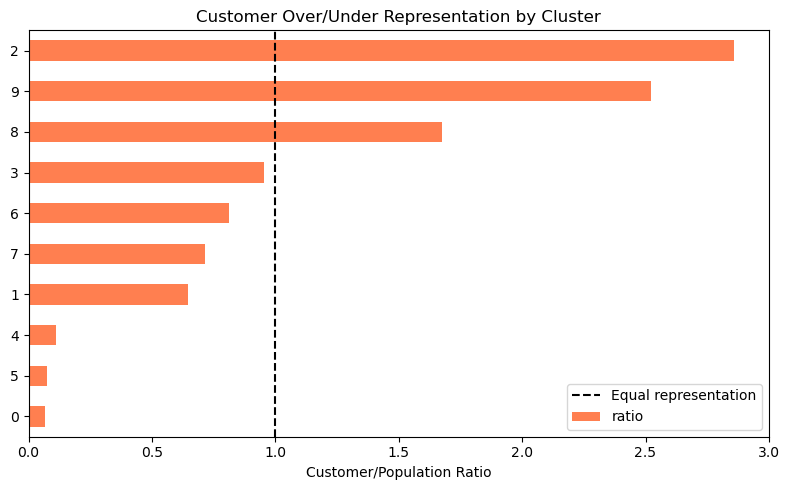

In [44]:
# Visualization
comparison['ratio'].sort_values().plot(
    kind='barh', figsize=(8, 5), color='coral'
)
plt.axvline(x=1, color='black', linestyle='--', label='Equal representation')
plt.title('Customer Over/Under Representation by Cluster')
plt.xlabel('Customer/Population Ratio')
plt.legend()
plt.tight_layout()
plt.show()

## Customer Profiling  
* selecting the target population   
* adding persona for each target cluster

In [45]:
# Adding a new column of clusters
azdias_profiling = azdias_clean.copy()
azdias_profiling['Cluster'] = azdias_clusters

# The average for each cluster
cluster_profiles = azdias_profiling.groupby('Cluster').mean()
print(cluster_profiles.shape)     # (n_clusters, n_features)

(10, 151)


In [46]:
# Selection the top target and non target clusters
target_clusters     = comparison_sorted.head(3).index.tolist()
non_target_clusters = comparison_sorted.tail(3).index.tolist()

print("Target clusters    :", target_clusters)
print("Non-target clusters:", non_target_clusters)

# 
target_profile     = cluster_profiles.loc[target_clusters].mean()
non_target_profile = cluster_profiles.loc[non_target_clusters].mean()

Target clusters    : [2, 9, 8]
Non-target clusters: [4, 5, 0]


In [47]:
# Extracting the features that differs between customers and not customers
diff = customers_clean.mean() - azdias_clean.mean()

top_features = (diff.abs()
                .sort_values(ascending=False)
                .head(10)
                .index.tolist())

print("Top 10 most distinguishing features:")
for f in top_features:
    direction = "↑ Higher in customers" if diff[f] > 0 else "↓ Lower in customers"
    print(f"  {f:30s}  {direction}  (diff={diff[f]:+.3f})")

Top 10 most distinguishing features:
  KBA13_ANZAHL_PKW                ↑ Higher in customers  (diff=+36.061)
  LP_LEBENSPHASE_FEIN             ↑ Higher in customers  (diff=+8.036)
  ANZ_HAUSHALTE_AKTIV             ↓ Lower in customers  (diff=-3.923)
  PRAEGENDE_JUGENDJAHRE           ↓ Lower in customers  (diff=-3.733)
  LP_LEBENSPHASE_GROB             ↑ Higher in customers  (diff=+2.179)
  HH_EINKOMMEN_SCORE              ↓ Lower in customers  (diff=-1.296)
  SEMIO_LUST                      ↑ Higher in customers  (diff=+1.007)
  WEALTH                          ↓ Lower in customers  (diff=-0.904)
  FINANZ_MINIMALIST               ↑ Higher in customers  (diff=+0.889)
  FINANZ_VORSORGER                ↑ Higher in customers  (diff=+0.782)


In [48]:
# mapping the top distinguishing features
def decode_feature(col, val):
    v = round(val)
    maps = {
        # --- Demographics ---
        'ALTERSKATEGORIE_GROB': {1:'Under 30', 2:'30-45', 3:'46-60', 4:'Over 60'},
        'ANREDE_KZ': {1:'Male', 2:'Female'},
        
        # --- Life Stage (Rough Scale) ---
        'LP_LEBENSPHASE_GROB': {
            1:'Younger Single Earner', 2:'Older Single Earner', 3:'High-Income Single',
            4:'Low/Average Couple', 5:'High-Income Couple', 6:'Single Parents',
            7:'Low/Average Family', 8:'High-Income Family', 9:'Younger Multi-person HH',
            10:'Older Multi-person HH', 11:'Younger High-Income Multi-person HH', 12:'Older High-Income Multi-person HH'
        },

        # --- Financial Status & Mindset ---
        'HH_EINKOMMEN_SCORE': {
            1:'Highest Income', 2:'Very High Income', 3:'High Income',
            4:'Average Income', 5:'Lower Income', 6:'Very Low Income'
        },
        'FINANZ_MINIMALIST': {
            1:'Very High interest', 2:'High', 3:'Average', 4:'Low', 5:'Very Low interest'
        },
        'FINANZ_VORSORGER': {
            1:'Very High (Prepared)', 2:'High', 3:'Average', 4:'Low', 5:'Very Low'
        },

        # --- Generation & Personality ---
        'PRAEGENDE_JUGENDJAHRE': {
            1:'40s War Years', 2:'40s Reconstruction', 3:'50s Economic Miracle', 
            4:'50s Individualisation', 5:'60s Economic Miracle', 8:'70s Family Orientation',
            9:'70s - peace movement',10:'80s Generation Golf',12:'80s Communist Youth',
             13:'80s - Swords into ploughshares' ,14:'90s Digital Media'
        },
        'SEMIO_LUST': {
            1:'Very Sensual', 2:'Sensual', 3:'Average', 4:'Less', 5:'Not Sensual', 6:'Very Not', 7:'Extremely Not'
        }
    }

    if col in maps:
        return maps[col].get(v, f"Value={v}")
    elif col == 'KBA13_ANZAHL_PKW':
        return f"{val:.0f} Cars in Region"
    else:
        return f"{val:.2f}"

In [49]:

PERSONA_FEATURES = [
    # Demographics (Essential)
    ('ALTERSKATEGORIE_GROB', 'Age Group'),
    ('ANREDE_KZ',            'Gender'),
    
    # Life Stage (Keep the rough scale only)
    ('LP_LEBENSPHASE_GROB',  'Life Stage'), 
    
    # Financial (The most impactful)
    ('HH_EINKOMMEN_SCORE',   'Household Income'),
    ('FINANZ_MINIMALIST',    'Financial Interest'),
    ('FINANZ_VORSORGER',     'Financial Preparation'),

    # Generation & Environment
    ('PRAEGENDE_JUGENDJAHRE','Generation'),
    ('KBA13_ANZAHL_PKW',     'Car Density in Region'),
    ('SEMIO_LUST',           'Personality: Sensual')
]
personas = {}
for cluster in cluster_profiles.index:
    data = cluster_profiles.loc[cluster]
    persona = {}
    for col, label in PERSONA_FEATURES:
        if col in data.index:
            persona[label] = decode_feature(col, data[col])
    personas[cluster] = persona

In [ ]:
persona_df = pd.DataFrame(personas).T

# defining the target clusters
target_clusters     = comparison_sorted.head(3).index.tolist()

display(persona_df.loc[target_clusters])


,Age Group,Gender,Life Stage,Household Income,Financial Interest,Financial Preparation,Generation,Car Density in Region,Personality: Sensual
2,30-45,Female,Low/Average Couple,Very High Income,Average,Average,70s - peace movement,551 Cars in Region,Not Sensual
9,46-60,Male,Low/Average Family,Very High Income,Very Low interest,Low,70s Family Orientation,695 Cars in Region,Not Sensual
8,46-60,Male,Younger High-Income Multi-person HH,Average Income,Low,Low,70s - peace movement,651 Cars in Region,Not Sensual


In [51]:
# non target clusters
non_target_clusters = comparison_sorted.tail(2).index.tolist()

display(persona_df.loc[non_target_clusters])

,Age Group,Gender,Life Stage,Household Income,Financial Interest,Financial Preparation,Generation,Car Density in Region,Personality: Sensual
5,30-45,Male,High-Income Single,Lower Income,High,High,80s - Swords into ploughshares,541 Cars in Region,Average
0,30-45,Female,High-Income Single,Very Low Income,Very High interest,High,80s Communist Youth,545 Cars in Region,Average
